<a href="https://colab.research.google.com/github/nourmoustafax/Crime_Analysis/blob/main/Crime_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/crimes.csv')

# Display the first few rows
display(df.head())

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA NAME,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,Weapon Desc,Status Desc,LOCATION
0,220314085,2022-07-22,2020-05-12,1110,Southwest,THEFT OF IDENTITY,27,F,B,NaN,Invest Cont,2500 S SYCAMORE AV
1,222013040,2022-08-06,2020-06-04,1620,Olympic,THEFT OF IDENTITY,60,M,H,NaN,Invest Cont,3300 SAN MARINO ST
2,220614831,2022-08-18,2020-08-17,1200,Hollywood,THEFT OF IDENTITY,28,M,H,NaN,Invest Cont,1900 TRANSIENT
3,231207725,2023-02-27,2020-01-27,635,77th Street,THEFT OF IDENTITY,37,M,H,NaN,Invest Cont,6200 4TH AV
4,220213256,2022-07-14,2020-07-14,900,Rampart,THEFT OF IDENTITY,79,M,B,NaN,Invest Cont,1200 W 7TH ST


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
import pandas as pd

# 1. Load the dataset
df = pd.read_csv('crimes.csv')

# 2. Clean Column Names
# Converts names like "Date Rptd" to "date_rptd" so they are easier to type
df.columns = df.columns.str.lower().str.replace(' ', '_')

# 3. Handle Missing Data
# 'weapon_desc' has over 112,000 missing values. We fill these with 'No Weapon'
# instead of dropping them, so we don't lose the rest of the crime data.
df['weapon_desc'] = df['weapon_desc'].fillna('No Weapon')

# 'vict_sex' and 'vict_descent' only have about 11 missing rows out of 185,000.
# It is safe to just drop these few incomplete rows.
df = df.dropna(subset=['vict_sex', 'vict_descent'])

# 4. Fix Datatypes
# Convert the date strings into actual Datetime objects for time-based analysis
df['date_rptd'] = pd.to_datetime(df['date_rptd'])
df['date_occ'] = pd.to_datetime(df['date_occ'])

# 5. Clean Time Column (Optional but recommended)
# 'time_occ' is in military time integers (e.g., 1340).
# Dividing by 100 extracts just the hour (13) which is much easier to analyze.
df['hour_occ'] = (df['time_occ'] // 100).astype(int)

# Check the results!
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 185703 entries, 0 to 185714
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   dr_no         185703 non-null  int64         
 1   date_rptd     185703 non-null  datetime64[ns]
 2   date_occ      185703 non-null  datetime64[ns]
 3   time_occ      185703 non-null  int64         
 4   area_name     185703 non-null  object        
 5   crm_cd_desc   185703 non-null  object        
 6   vict_age      185703 non-null  int64         
 7   vict_sex      185703 non-null  object        
 8   vict_descent  185703 non-null  object        
 9   weapon_desc   185703 non-null  object        
 10  status_desc   185703 non-null  object        
 11  location      185703 non-null  object        
 12  hour_occ      185703 non-null  int64         
dtypes: datetime64[ns](2), int64(4), object(7)
memory usage: 19.8+ MB
None


/tmp/ipykernel_903/163721921.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sex_counts, x='Vict Sex', y='Count', palette='viridis')


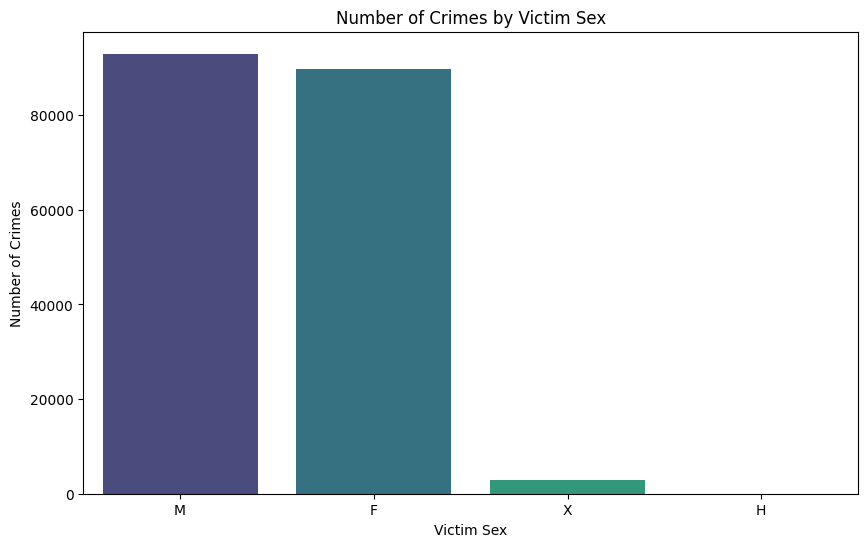

In [28]:
sex_counts = df['vict_sex'].value_counts().reset_index()
sex_counts.columns = ['Vict Sex', 'Count']

plt.figure(figsize=(10, 6))
sns.barplot(data=sex_counts, x='Vict Sex', y='Count', palette='viridis')
plt.title('Number of Crimes by Victim Sex')
plt.xlabel('Victim Sex')
plt.ylabel('Number of Crimes')
plt.show()

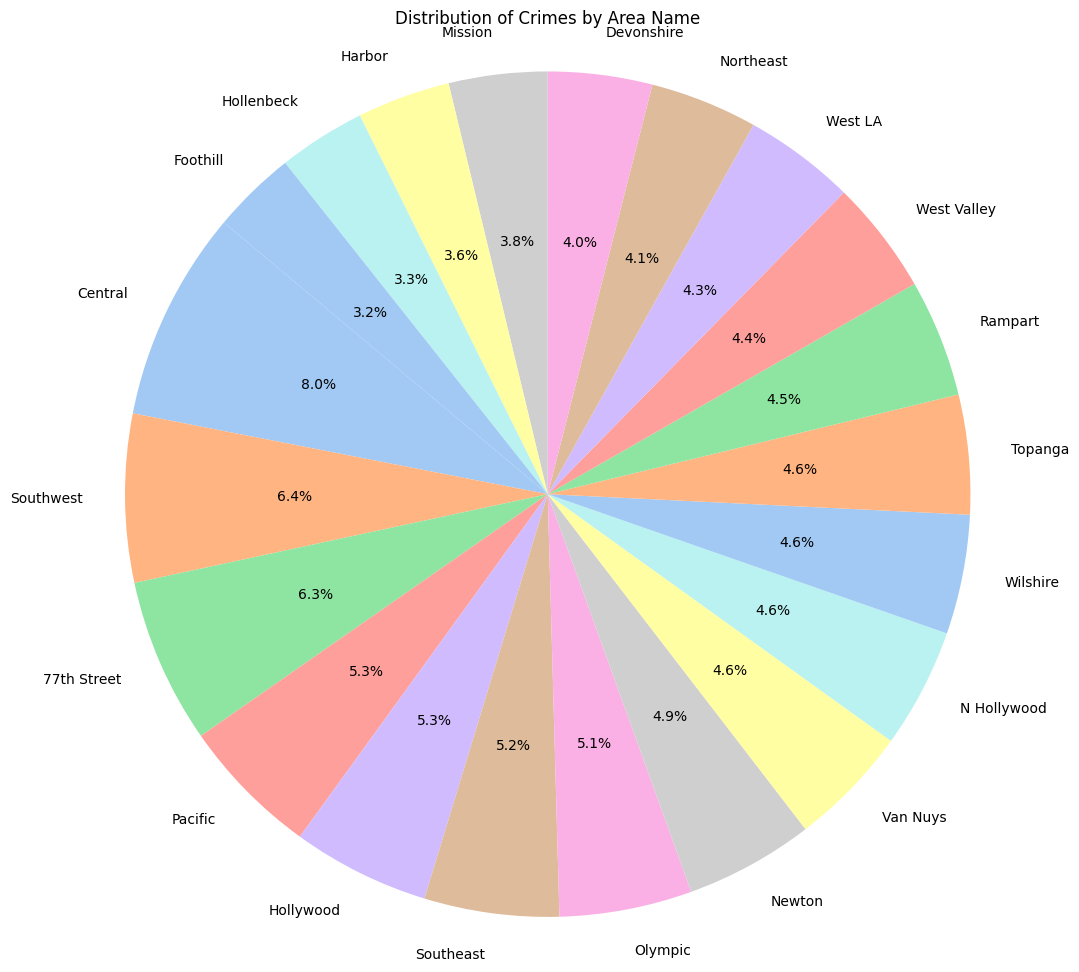

In [30]:
area_counts = df['area_name'].value_counts()

plt.figure(figsize=(12, 12))
plt.pie(area_counts, labels=area_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Distribution of Crimes by Area Name')
plt.axis('equal')
plt.show()

In [34]:
display(df.head())

,dr_no,date_rptd,date_occ,time_occ,area_name,crm_cd_desc,vict_age,vict_sex,vict_descent,weapon_desc,status_desc,location,hour_occ
0,220314085,2022-07-22,2020-05-12,1110,Southwest,THEFT OF IDENTITY,27,F,B,No Weapon,Invest Cont,2500 S SYCAMORE AV,11
1,222013040,2022-08-06,2020-06-04,1620,Olympic,THEFT OF IDENTITY,60,M,H,No Weapon,Invest Cont,3300 SAN MARINO ST,16
2,220614831,2022-08-18,2020-08-17,1200,Hollywood,THEFT OF IDENTITY,28,M,H,No Weapon,Invest Cont,1900 TRANSIENT,12
3,231207725,2023-02-27,2020-01-27,635,77th Street,THEFT OF IDENTITY,37,M,H,No Weapon,Invest Cont,6200 4TH AV,6
4,220213256,2022-07-14,2020-07-14,900,Rampart,THEFT OF IDENTITY,79,M,B,No Weapon,Invest Cont,1200 W 7TH ST,9


/tmp/ipykernel_903/201539913.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sex_counts, x='Vict Descent', y='Count', palette='viridis')


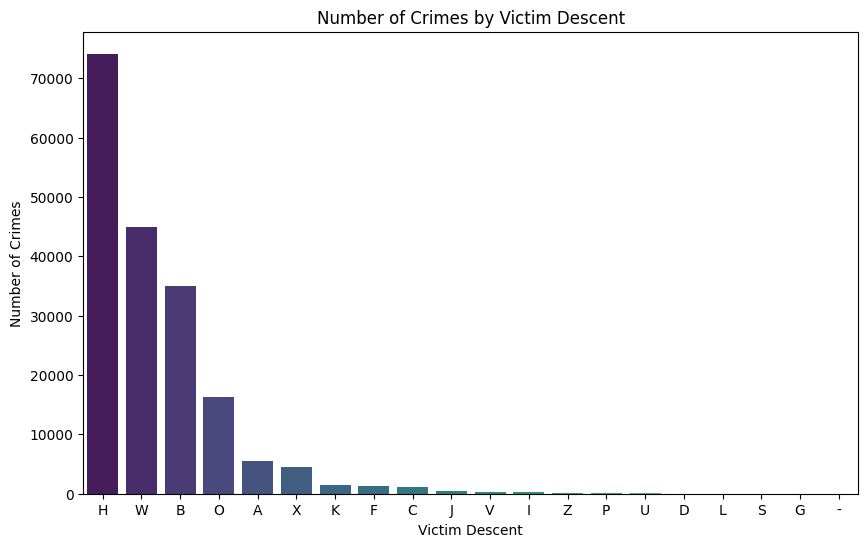

In [36]:
sex_counts = df['vict_descent'].value_counts().reset_index()
sex_counts.columns = ['Vict Descent', 'Count']

plt.figure(figsize=(10, 6))
sns.barplot(data=sex_counts, x='Vict Descent', y='Count', palette='viridis')
plt.title('Number of Crimes by Victim Descent')
plt.xlabel('Victim Descent')
plt.ylabel('Number of Crimes')
plt.show()

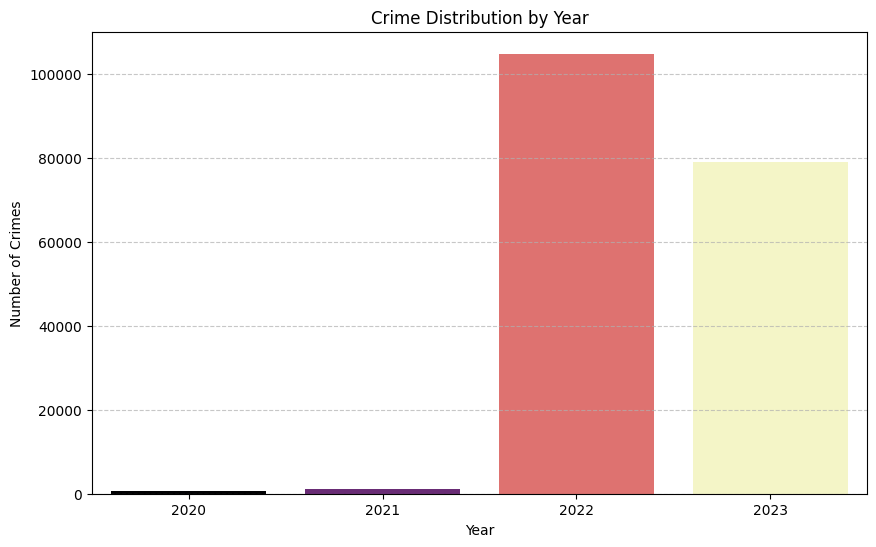

In [38]:
df['year_occ'] = df['date_occ'].dt.year

year_counts = df['year_occ'].value_counts().sort_index().reset_index()
year_counts.columns = ['Year', 'Crime Count']

plt.figure(figsize=(10, 6))
sns.barplot(data=year_counts, x='Year', y='Crime Count', palette='magma', hue='Year', legend=False)
plt.title('Crime Distribution by Year')
plt.xlabel('Year')
plt.ylabel('Number of Crimes')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [39]:
import pandas as pd
from scipy.stats import chi2_contingency

top_10_crimes = df['crm_cd_desc'].value_counts().head(10).index
df_top = df[df['crm_cd_desc'].isin(top_10_crimes)]

contingency_table = pd.crosstab(df_top['crm_cd_desc'], df_top['vict_sex'])
print(contingency_table)

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-Square Statistic: {chi2:.2f}")
print(f"P-value: {p_value:.5f}")

alpha = 0.05
if p_value < alpha:
    print("Result: Reject Null Hypothesis")
    print("Conclusion: There is a statistically significant relationship between crime type and victim sex.")
else:
    print("Result: Fail to Reject Null Hypothesis")
    print("Conclusion: No significant relationship was detected; differences are likely due to chance.")

vict_sex                                                F   H      M    X
crm_cd_desc                                                              
ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT       3672   0   9411  131
BATTERY - SIMPLE ASSAULT                             9198   2  10409   84
BURGLARY                                             4066   0   5929  271
BURGLARY FROM VEHICLE                                5829   3   7903   63
INTIMATE PARTNER - SIMPLE ASSAULT                    9126   0   2847    8
THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND O...   4490   1   6931   61
THEFT OF IDENTITY                                   14426  11   8176   57
THEFT PLAIN - PETTY ($950 & UNDER)                   5314   5   5147  136
THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LIV...   3313   0   3621  122
VANDALISM - FELONY ($400 & OVER, ALL CHURCH VAN...   4877   2   5576  262
Chi-Square Statistic: 9898.53
P-value: 0.00000
Result: Reject Null Hypothesis
Conclusion: There is a statistical

In [40]:
import pandas as pd

df['date_rptd'] = pd.to_datetime(df['date_rptd'])
df['date_occ'] = pd.to_datetime(df['date_occ'])

df['reporting_lag'] = (df['date_rptd'] - df['date_occ']).dt.days

crime_lag_analysis = df.groupby('crm_cd_desc')['reporting_lag'].agg(['mean', 'median', 'count'])

min_incidents = 100
filtered_analysis = crime_lag_analysis[crime_lag_analysis['count'] >= min_incidents]

top_delayed_crimes = filtered_analysis.sort_values(by='mean', ascending=False).head(10)

print("Top 10 Crimes with Longest Reporting Lag (Average Days):")
print(top_delayed_crimes)

Top 10 Crimes with Longest Reporting Lag (Average Days):
                                                          mean  median  count
crm_cd_desc                                                                  
CRM AGNST CHLD (13 OR UNDER) (14-15 & SUSP 10 Y...  183.644491    16.0    481
EMBEZZLEMENT, GRAND THEFT ($950.01 & OVER)          101.318182    21.0    176
ORAL COPULATION                                      92.244186     2.0    172
DOCUMENT FORGERY / STOLEN FELONY                     85.493810    28.0    727
UNAUTHORIZED COMPUTER ACCESS                         83.230769    13.0    117
THEFT OF IDENTITY                                    56.671813     4.0  22670
BUNCO, GRAND THEFT                                   43.140741     5.0   1755
STALKING                                             35.090909     1.0    198
BUNCO, PETTY THEFT                                   21.714894     2.0    470
THREATENING PHONE CALLS/LETTERS                      20.544554     1.0    101


In [41]:
crime_counts = df['crm_cd_desc'].value_counts()
cumulative_percentage = crime_counts.cumsum() / crime_counts.sum() * 100

# Top crimes that make up 50% of all reported incidents
top_crimes_50 = cumulative_percentage[cumulative_percentage <= 50]
print("These crimes represent 50% of all incidents in the dataset:")
print(top_crimes_50)

These crimes represent 50% of all incidents in the dataset:
crm_cd_desc
THEFT OF IDENTITY                                      12.207665
BATTERY - SIMPLE ASSAULT                               22.812232
BURGLARY FROM VEHICLE                                  30.242376
ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT         37.358039
INTIMATE PARTNER - SIMPLE ASSAULT                      43.809739
THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND OVER)    49.993269
Name: count, dtype: float64


In [42]:
bins = [0, 18, 30, 50, 70, 100]
labels = ['Minor', 'Young Adult', 'Adult', 'Senior', 'Elderly']
df['age_group'] = pd.cut(df['vict_age'], bins=bins, labels=labels)

age_crime_pivot = pd.crosstab(df['age_group'], df['crm_cd_desc'])
# Top crime for each age group
for group in labels:
    top_crime = age_crime_pivot.loc[group].idxmax()
    print(f"Most common crime for {group}: {top_crime}")

Most common crime for Minor: BATTERY - SIMPLE ASSAULT
Most common crime for Young Adult: THEFT OF IDENTITY
Most common crime for Adult: THEFT OF IDENTITY
Most common crime for Senior: BATTERY - SIMPLE ASSAULT
Most common crime for Elderly: BURGLARY


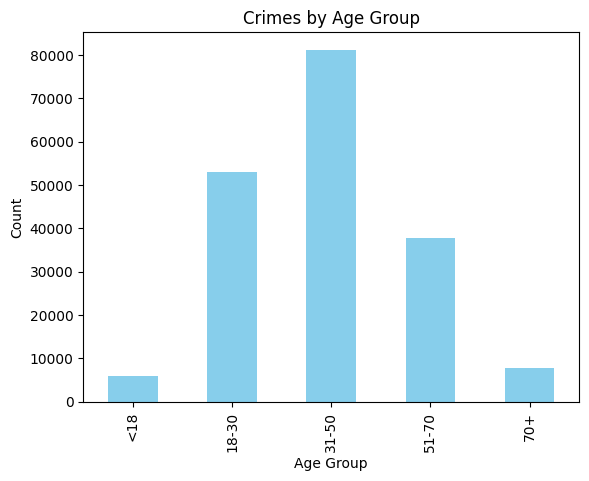

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Create age groups
bins = [0, 18, 30, 50, 70, 100]
labels = ['<18', '18-30', '31-50', '51-70', '70+']
df['age_group'] = pd.cut(df['vict_age'], bins=bins, labels=labels)

# 2. Count and Plot
df['age_group'].value_counts().reindex(labels).plot(kind='bar', color='skyblue')

plt.title('Crimes by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.show()

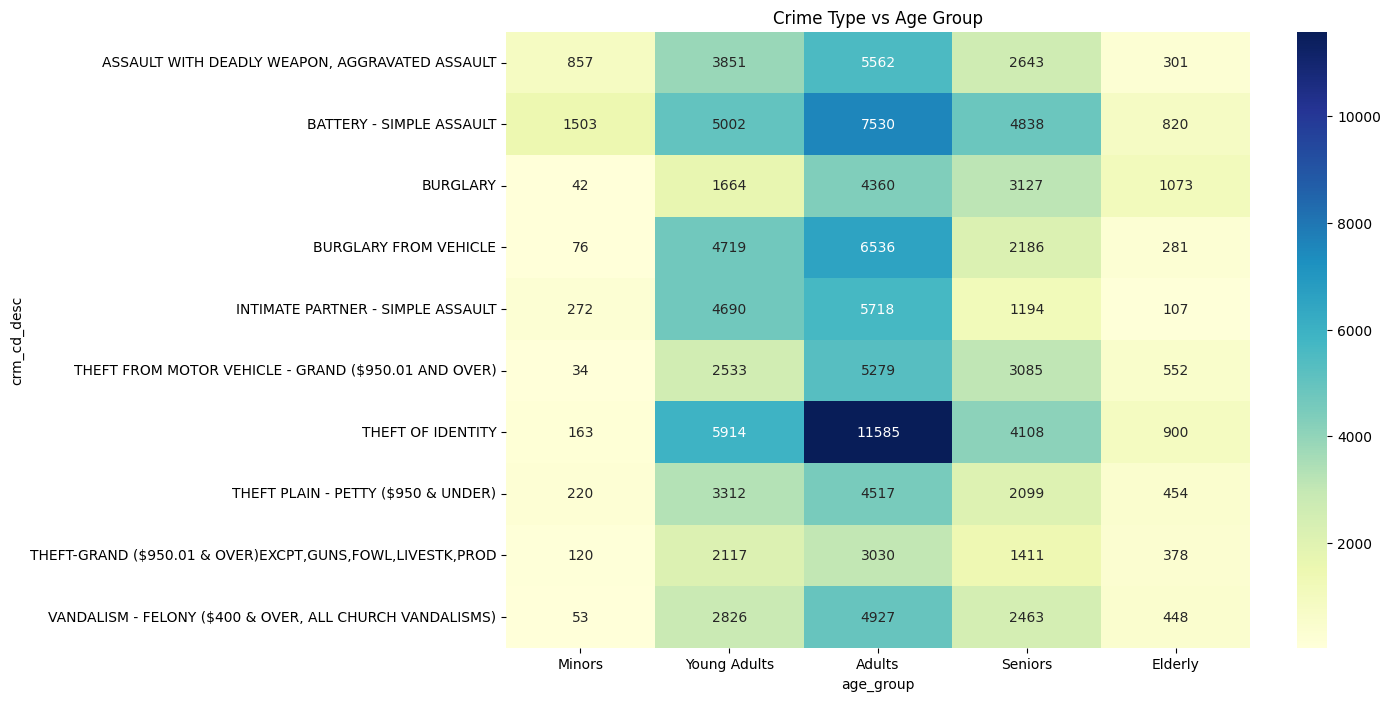

In [44]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

bins = [0, 18, 30, 50, 70, 100]
labels = ['Minors', 'Young Adults', 'Adults', 'Seniors', 'Elderly']
df['age_group'] = pd.cut(df['vict_age'], bins=bins, labels=labels)

top_10_crimes = df['crm_cd_desc'].value_counts().head(10).index
df_filtered = df[df['crm_cd_desc'].isin(top_10_crimes)]

age_crime_matrix = pd.crosstab(df_filtered['crm_cd_desc'], df_filtered['age_group'])

plt.figure(figsize=(12, 8))
sns.heatmap(age_crime_matrix, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Crime Type vs Age Group')
plt.show()